# Preliminaries

## Dataset

In this set of exercises we will use the same dataset as from [week 3](week_3.ipynb). 


As before, we provide the data already curated in the following two files:

`RNA_expression_curated.csv`: [148 cell lines , 238 genes]

`drug_response_curated.csv`: [148 cell lines , YM155 drug]

The curated data can be read as `pandas` `DataFrame` in the following way:

In [2]:
import pandas as pd

gene_expression = pd.read_csv("./data/RNA_expression_curated.csv", sep=',', header=0, index_col=0)
drug_response = pd.read_csv("./data/drug_response_curated.csv", sep=',', header=0, index_col=0)

The goal of the exercises is to train support vector machine (SVM) and random forests classifiers on this dataset and explore and learn about their hyperparameters. 

## Tools

The `scikit-learn` library provides the required tools for support vector machines, as well as for random forest algorithms.

In [5]:
from sklearn import svm 
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_blobs, make_circles
from sklearn.metrics import classification_report

Before proceeding, look up the documentation of the imported functions and read about their basic functionality. Below, we list some important parameters of SVMs and random forests that can be tuned during training.

#### Support Vector Machines (SVM)

`C`: error term.

`kernel`: similarity function ('linear', 'poly', 'sigmoid' or 'rbf')

`gamma`: kernel coef. for 'rbf', 'poly' and 'sigmoid' kernels. It can be thought of as the ‘spread’ of the kernel and therefore the decision region.

`degree`: degree for the 'poly' kernel.

`coef0`: independt term in the 'poly' and 'sigmoid' kernels


#### Random Forests

`n_estimators`: number of trees in our random forest.

`max_depth`: maximum number of levels in each decision tree

`max_features`: maximum number of features to consider per split in an individual tree.

`min_sample_leaf`: minimum number of data points per leaf node

`min_samples_split`: minimum number of data points placed in a node before the node is split

`oob_score`: the out-of-bag (OOB) error is the average error for each observation calculated using predictions from the trees that do not contain that observation in their respective bootstrap sample. Set this parameter to true.

`bootstrap`: method for sampling data points (with or without replacement). Set this parameter to true.

`criterion`: function used to measure the quality of the split (e.g. 'entropy' or 'gini')

# Exercises

## Support vector machines

The  `make_blobs` and `make_circles` functions can be used to generate linearly and not linearly separable toy datasets. 

In [8]:
# data generation: linearly separable
X, Y = make_blobs(n_samples=200, centers=2, n_features=2, random_state=1234)
X = pd.DataFrame(X, columns=['x1', 'x2'])

# splitting data into training and test set
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.33, random_state=333)

The following code illustrates how to train a linear SVM classifier and plot the data points, the separating hyperplane, the support vectors and the margins that pass through them (considering the training data)

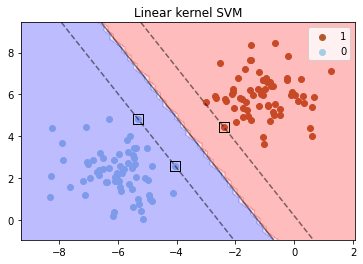

In [10]:
import numpy as np
import matplotlib.pyplot as plt

model = svm.SVC(kernel='linear', random_state=33)
model.fit(X_train, Y_train)

fig, ax = plt.subplots()
cmap = plt.cm.get_cmap('Paired')

ax.scatter(X_train.iloc[Y_train == 1, 0], X_train.iloc[Y_train == 1, 1],
           c=[cmap(11)], label='1')
ax.scatter(X_train.iloc[Y_train == 0, 0], X_train.iloc[Y_train == 0, 1],
           c=[cmap(0)], label='0')
ax.legend(loc='best')

x1_min, x1_max = X_train.iloc[:, 0].min() - 1, X_train.iloc[:, 0].max() + 1
x2_min, x2_max = X_train.iloc[:, 1].min() - 1, X_train.iloc[:, 1].max() + 1

XX, YY = np.meshgrid(np.arange(x1_min, x1_max, .2),
                     np.arange(x2_min, x2_max, .2))

xy = np.vstack([XX.ravel(), YY.ravel()]).T
Z = model.decision_function(xy).reshape(XX.shape)

ax.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1], alpha=0.5,
           linestyles=['--', '-', '--'])

Z = model.predict(xy).reshape(XX.shape)

ax.contourf(XX, YY, Z, cmap='bwr', alpha=0.3)

ax.scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1], s=100,
           linewidth=1, facecolors='none', edgecolors='k', marker='s')

ax.axis([x1_min, x1_max, x2_min, x2_max])
plt.axis('tight')
plt.title('Linear kernel SVM')
plt.show()

Train a radial basis function (RBF) SVM classifier with `gamma=0.5` and plot the results in the same way.

In [12]:
# data generation: not linearly separable
X, Y = make_circles(n_samples=200, noise=0.05, random_state=1234)
X = pd.DataFrame(X, columns=['x1', 'x2'])

# splitting data into training and test set
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.33, random_state=333)

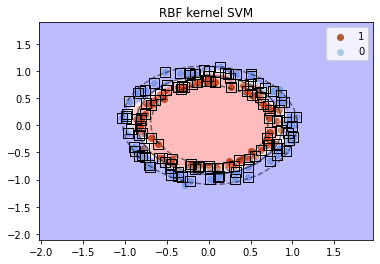

In [13]:
import numpy as np
import matplotlib.pyplot as plt

model = svm.SVC(kernel='rbf', gamma = 0.5, random_state=33, C=1)
model.fit(X_train, Y_train)

fig, ax = plt.subplots()

cmap = plt.cm.get_cmap('Paired')

ax.scatter(X_train.iloc[Y_train == 1, 0], X_train.iloc[Y_train == 1, 1],
           c=[cmap(11)], label='1')
ax.scatter(X_train.iloc[Y_train == 0, 0], X_train.iloc[Y_train == 0, 1],
           c=[cmap(0)], label='0')
ax.legend(loc='best')

x1_min, x1_max = X_train.iloc[:, 0].min() - 1, X_train.iloc[:, 0].max() + 1
x2_min, x2_max = X_train.iloc[:, 1].min() - 1, X_train.iloc[:, 1].max() + 1

XX, YY = np.meshgrid(np.arange(x1_min, x1_max, .2),
                     np.arange(x2_min, x2_max, .2))

xy = np.vstack([XX.ravel(), YY.ravel()]).T
Z = model.decision_function(xy).reshape(XX.shape)

ax.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1], alpha=0.5,
           linestyles=['--', '-', '--'])

Z = model.predict(xy).reshape(XX.shape)

ax.contourf(XX, YY, Z, cmap='bwr', alpha=0.3)

ax.scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1], s=100,
           linewidth=1, facecolors='none', edgecolors='k', marker='s')

ax.axis([x1_min, x1_max, x2_min, x2_max])
plt.axis('tight')
plt.title('RBF kernel SVM')
plt.show()

<p><font color='#770a0a'>When should a RBF kernel be used over a linear kernel? Motivate your answer.</font></p>

**Answer**: RBF kernels should be used when the data is not linearly seperable and therefore when a nonlinear decision boundary is needed to correctly classify the samples. In the example above, the dataset forms two circles which can never be separated using a linear kernel, while the RBF kernel successfully models the circular boundary.

<p><font color='#770a0a'>Do we need to normalize the data before using a kernel function? Motivate your answer.
</font></p>

**Answer**: Yes, because most kernels depend the distance between data points. If features are not normalised, they can be on completely different scales. As a result, features with larger scales will dominate. Normalizing the features will make sure that all features contribute equally. 

## Predicting drug response on cell lines from gene expression data with SVMs

Explore the hyper-parameter space of an SVM classifier with cross-validation for the Genomics of Drug Sensitivity in Cancer (GDSC) dataset. The`GridSearchCV` function can be used to specify a grid of parameter values with the `param_grid` parameter.

In [16]:
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

print("RNA shape:", gene_expression.shape)
print("Response shape:", drug_response.shape)

Y = (drug_response < 0).astype(int).squeeze()

print("Class division (0=resistant, 1=sensitive):", np.bincount(Y))

X_train, X_test, Y_train, Y_test = train_test_split(gene_expression, Y, test_size=0.3, random_state=42, stratify=Y)

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', svm.SVC())
])

param_grid = {
    'svm__kernel': ['linear','rbf'],        
    'svm__C': [0.1, 1, 10, 100],
    'svm__gamma': [0.01, 0.1, 0.5, 1, 5]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=cv,
    scoring='accuracy',    
    n_jobs=-1,
    verbose=1
)


grid_search.fit(X_train, Y_train)


print("Best parameters", grid_search.best_params_)
print("Best cross-validation accuracy:", grid_search.best_score_)


RNA shape: (148, 238)
Response shape: (148, 1)
Class division (0=resistant, 1=sensitive): [ 32 116]
Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best parameters {'svm__C': 0.1, 'svm__gamma': 0.01, 'svm__kernel': 'linear'}
Best cross-validation accuracy: 0.8338095238095239


Calculate the precision of your predictions, and compare your calculations with the results of `classification_report`, which displays many classification metrics.

In [18]:
from sklearn.metrics import confusion_matrix

y_pred = grid_search.best_estimator_.predict(X_test)

cm = confusion_matrix(Y_test, y_pred)
TP = cm[1, 1]
FP = cm[0, 1]
precision_manual = TP / (TP + FP)
print("Manual precision:", precision_manual)

report = classification_report(Y_test, y_pred)
print(report)

Manual precision: 0.8333333333333334
              precision    recall  f1-score   support

           0       0.44      0.40      0.42        10
           1       0.83      0.86      0.85        35

    accuracy                           0.76        45
   macro avg       0.64      0.63      0.63        45
weighted avg       0.75      0.76      0.75        45



**Comparison**: The manually calculated precision (0.833) is the same as the precision from the classification report for class 1 (0.83). The classification report does round the precision to two decimals though. Still, it shows that the precision metric in the report is computed as TP / (TP + FP), which is exactly what the manual calculation does. 

## Random forests

Follow the same steps as for SVM. Compare the two algorithms and report which one has better performance.

In [21]:
pipe_rf = Pipeline([
    ('rf', RandomForestClassifier(random_state=0, n_jobs=-1, bootstrap=True))    # n_jobs = -1, trains all trees in parallel (faster)
])

param_grid_rf = {
    'rf__n_estimators': [200, 400, 800],
    'rf__max_depth': [None, 10, 20, 40],
    'rf__max_features': ['sqrt', 'log2', None],
    'rf__min_samples_split': [2, 5, 10],
    'rf__min_samples_leaf': [1, 2, 4],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

grid_search_rf = GridSearchCV(
    estimator=pipe_rf,
    param_grid=param_grid_rf,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search_rf.fit(X_train, Y_train)

print("Best RF parameters:", grid_search_rf.best_params_)
print("Best RF CV accuracy:", grid_search_rf.best_score_)

y_pred = grid_search_rf.best_estimator_.predict(X_test)
cm = confusion_matrix(Y_test, y_pred)
TP = cm[1, 1]
FP = cm[0, 1]
precision_manual = TP / (TP + FP)
print("RF Manual precision:", precision_manual)

print("RF classification report:")
print(classification_report(Y_test, y_pred))

Fitting 5 folds for each of 324 candidates, totalling 1620 fits
Best RF parameters: {'rf__max_depth': None, 'rf__max_features': 'log2', 'rf__min_samples_leaf': 1, 'rf__min_samples_split': 5, 'rf__n_estimators': 200}
Best RF CV accuracy: 0.8257142857142856
RF Manual precision: 0.813953488372093
RF classification report:
              precision    recall  f1-score   support

           0       1.00      0.20      0.33        10
           1       0.81      1.00      0.90        35

    accuracy                           0.82        45
   macro avg       0.91      0.60      0.62        45
weighted avg       0.86      0.82      0.77        45



**Comparison**: The random forest model achieved a precision of 0.81 for class 1 (sensitive), while the support vector machine reached a slightly higher precision of 0.83. These values are within a similar range and therefore indicating comparable performance between the two models. However, the test set is relatively small due to the limited dataset size. The dataset contains 148 samples. So, a 30% test split results in only 45 samples for testing. Because a stratified split was used, 35 samples belong to class 1 (sensitive) and 10 to class 0 (resistant). The resulting precision of 1.0 for class 0 is therefore not reliable because it is based on a very small number of samples. To obtain more robust and generalizable results, future studies should use a larger dataset.

The random forests classifiers allows to perform feature selection. Evaluate the importance of features extracting the top 50 informative features. A bar plot (`plt.bar()`) can be a useful tool to visualize this. 

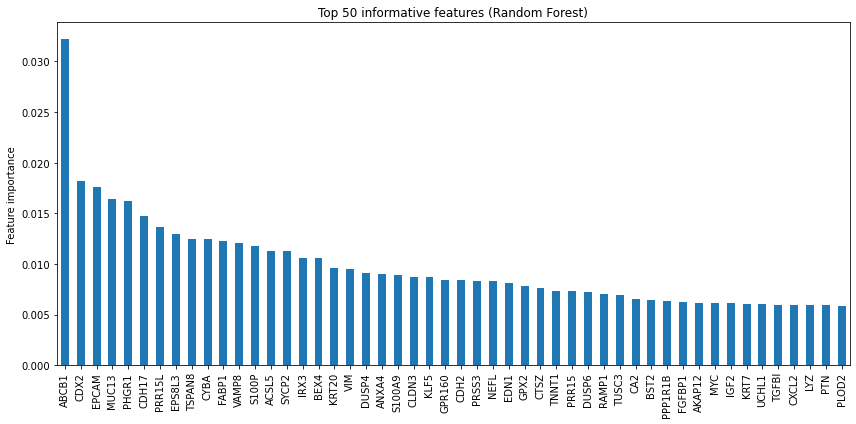

In [23]:
rf_best = grid_search_rf.best_estimator_.named_steps['rf']
importances = rf_best.feature_importances_
features = X_train.columns

feat_imp = pd.Series(importances, index=features).sort_values(ascending=False).head(50)

plt.figure(figsize=(12, 6))
feat_imp.plot(kind='bar')
plt.title('Top 50 informative features (Random Forest)')
plt.ylabel('Feature importance')
plt.tight_layout()
plt.show()

## Biomedical applications

Driven by technological advances, there has recently been a dramatic increase in availability of biomedical data. Machine learning approaches are well suited to take advantage of this data and have been widely applied to many areas of biology. 

Example of these applications are genome annotation, biomarker identification, systems biology, genome data analysis, protein  function  prediction, protein  structure prediction, protein localization prediction, identification of protein interactions and drug discovery.

SVM and RF methods are among the most popular machine learning methods applied in bioinformatics or computational biology.

Perform a literature search and find a biomedical study in which SVM or RF is applied to obtain certain insights. <p><font color='#770a0a'>Explain the motivation behind using that specific algorithm in the study.
</font></p>

**Answer:** The article “Prediction of protein–protein interactions using random decision forest framework” (Chen & Liu, 2005) presents a method to predict how proteins interact based on the functional building blocks, the domains. A random forest model is used that combines information from all possible domain combinations. The motivation for using a random forest model was to overcome the limitations of earlier statistical models that assumed that there is no relationship  between domain pair interactions and typically considered only single domain pairs. The random forest approach allowed to explore all possible domain combinations within protein pairs and therefore capturing complex relationships among domains.